In [12]:
import pandas as pd
import joblib
import dill
from sklearn.preprocessing import StandardScaler
from incdbscan.incrementaldbscan import IncrementalDBSCAN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [13]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from hdbscan.validity import validity_index as dbcv_validity_index

In [14]:
# --- Định nghĩa cấu hình ---
METRICS = [
    'Velocity_Anomaly',
    'Value_Anomaly',
    'TimeGap_Anomaly',
    'Location_Anomaly',
    'Network_Anomaly'
]
EPS_VALUE = 0.7
MIN_SAMPLES_VALUE = 6
MODEL_FILENAME = 'model.pkl'
SCALER_FILENAME = 'scaler.pkl'

# --- Load dữ liệu lịch sử ---
data_history = pd.read_csv('data_history_min.csv')
X_history = data_history[METRICS].fillna(0)

# --- Tạo, Huấn luyện (fit) và Lưu Standard Scaler ---
scaler = StandardScaler()
scaler.fit(X_history)
joblib.dump(scaler, SCALER_FILENAME)
print(f"✅ Scaler đã lưu vào '{SCALER_FILENAME}'")

# --- Scale dữ liệu lịch sử ---
X_history_scaled = scaler.transform(X_history)

# --- Huấn luyện IncrementalDBSCAN ---
idbscan_model = IncrementalDBSCAN(eps=EPS_VALUE, min_pts=MIN_SAMPLES_VALUE)
idbscan_model.insert(X_history_scaled)  # insert batch history

# --- Lấy nhãn cluster cho toàn bộ dữ liệu lịch sử ---
labels = idbscan_model.get_cluster_labels(X_history_scaled)
num_clusters = len(set(labels) - {-1})  # loại bỏ noise (-1)
print(f"Huấn luyện history hoàn tất. Số cụm: {num_clusters}")

# --- Thêm cột nhãn cluster và cột anomaly vào data_history ---
data_history_results = data_history.copy()
data_history_results['cluster_label'] = labels
data_history_results['is_anomaly'] = data_history_results['cluster_label'] == -1

# --- In vài dòng kết quả để kiểm tra ---
print("\n--- Kết quả Phân cụm Dữ liệu Lịch sử ---")
print(data_history_results.head(10))

# --- In các điểm bất thường ---
anomaly_history = data_history_results[data_history_results['is_anomaly']]
if not anomaly_history.empty:
    print(f"\n💡 Phát hiện {len(anomaly_history)} điểm ANOMALY (label = -1) trong dữ liệu lịch sử:")
    print(anomaly_history[['transaction_id', 'sender_account', 'Velocity_Anomaly', 'Value_Anomaly',
                           'TimeGap_Anomaly', 'cluster_label', 'is_anomaly']])

✅ Scaler đã lưu vào 'scaler.pkl'
Huấn luyện history hoàn tất. Số cụm: 6

--- Kết quả Phân cụm Dữ liệu Lịch sử ---
   transaction_id            timestamp sender_account receiver_account  \
0            4947  2025-05-01 00:03:00    ACC72727011      ACC20053358   
1            2926  2025-05-01 00:04:00    ACC70847404      ACC42997680   
2            2903  2025-05-01 00:32:00    ACC57391095      ACC30818005   
3            7566  2025-05-01 01:45:00    ACC51450856      ACC25950190   
4            5670  2025-05-01 01:48:00    ACC54501777      ACC96809814   
5            5700  2025-05-01 02:09:00    ACC90771158      ACC59898608   
6            4993  2025-05-01 02:13:00    ACC13065064      ACC23805217   
7               1  2025-05-01 02:50:00    ACC83943848      ACC63535885   
8            3382  2025-05-01 03:18:00    ACC65067486      ACC35928416   
9            7222  2025-05-01 03:34:00    ACC47962723      ACC87961799   

   amount   location       ip_address                       device_hash

In [15]:
# Phan bo diem du lieu theo cum
n_clusters = len(np.unique(labels[labels != -1]))
n_noise = np.sum(labels == -1)
n_total = len(labels)
noise_ratio = n_noise / n_total

print(f"  Tổng số điểm dữ liệu ban đầu: {n_total}")
print(f"  Số cụm được phát hiện ban đầu: {n_clusters}")
print(f"  Số điểm nhiễu (anomaly)ban đầu: {n_noise}")
print(f"  Tỷ lệ nhiễu ban đầu: {noise_ratio:.2%}")
print(f"\nPHÂN BỐ ĐIỂM DỮ LIỆU THEO CỤM BAN ĐẦU:")
print("-----------------------------")

cluster_counts = pd.Series(labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = count / n_total
    if cluster_id == -1:
        print(f"  Cluster {cluster_id} (NOISE): {count} diem ({percentage:.1%})")
    else:
        print(f"  Cluster {cluster_id}: {count} diem ({percentage:.1%})")

  Tổng số điểm dữ liệu ban đầu: 8000
  Số cụm được phát hiện ban đầu: 6
  Số điểm nhiễu (anomaly)ban đầu: 615
  Tỷ lệ nhiễu ban đầu: 7.69%

PHÂN BỐ ĐIỂM DỮ LIỆU THEO CỤM BAN ĐẦU:
-----------------------------
  Cluster -1.0 (NOISE): 615 diem (7.7%)
  Cluster 22.0: 7276 diem (91.0%)
  Cluster 25.0: 74 diem (0.9%)
  Cluster 26.0: 11 diem (0.1%)
  Cluster 27.0: 13 diem (0.2%)
  Cluster 28.0: 5 diem (0.1%)
  Cluster 29.0: 6 diem (0.1%)


In [16]:
def evaluate_clustering(X, labels):
    # Bảo đảm là ndarray
    X = np.asarray(X)
    labels = np.asarray(labels)

    # Bỏ noise
    mask = labels != -1
    if mask.sum() < 2:
        return {"Silhouette": np.nan, "DBI": np.nan, "CH": np.nan, "DBCV": np.nan}

    # Ít nhất 2 cụm hợp lệ
    labels_masked = labels[mask]
    uniq = np.unique(labels_masked)
    if len(uniq) < 2:
        return {"Silhouette": np.nan, "DBI": np.nan, "CH": np.nan, "DBCV": np.nan}

    # Map nhãn về 0..k-1 nhanh bằng return_inverse
    Xm = X[mask].astype(np.float64, copy=False)
    _, labels_mapped = np.unique(labels_masked, return_inverse=True)

    sil = silhouette_score(Xm, labels_mapped)
    dbi = davies_bouldin_score(Xm, labels_mapped)
    ch  = calinski_harabasz_score(Xm, labels_mapped)
    dbcv = dbcv_validity_index(Xm, labels_mapped)  # metric="euclidean" mặc định

    return {"Silhouette": sil, "DBI": dbi, "CH": ch, "DBCV": dbcv}

In [17]:
# --- 1. Định nghĩa cấu hình ---
METRICS = [
    'Velocity_Anomaly',
    'Value_Anomaly',
    'TimeGap_Anomaly',
    'Location_Anomaly',
    'Network_Anomaly'
]
MODEL_FILENAME = 'model.pkl'
SCALER_FILENAME = 'scaler.pkl'

# --------------------------------------------------------------------------
# --- 3. Load dữ liệu streaming ---
# --------------------------------------------------------------------------
data_streaming = pd.read_csv('data_stream_min.csv')  # dữ liệu mới
X_streaming = data_streaming[METRICS].fillna(0)

# --- 4. Scale dữ liệu streaming ---
X_streaming_scaled = scaler.transform(X_streaming)

# --- 5. Chèn dữ liệu streaming vào mô hình IncrementalDBSCAN ---
idbscan_model.insert(X_streaming_scaled)

# --- 6. Lấy nhãn cluster cho dữ liệu streaming ---
streaming_labels = idbscan_model.get_cluster_labels(X_streaming_scaled)

# --- 7. Gắn nhãn cluster và anomaly vào bảng streaming ---
streaming_results = data_streaming.copy()
streaming_results['cluster_label'] = streaming_labels
streaming_results['is_anomaly'] = streaming_results['cluster_label'] == -1

# --- 8. In kết quả toàn bộ streaming ---
print("\n--- Kết quả Phân cụm Dữ liệu Streaming ---")
print(streaming_results.head(10))  # in 10 dòng đầu

# --- 9. In các điểm bất thường ---
anomaly_streaming = streaming_results[streaming_results['is_anomaly']]
if not anomaly_streaming.empty:
    print(f"\n💡 Phát hiện {len(anomaly_streaming)} điểm ANOMALY (label = -1) trong streaming:")
    print(anomaly_streaming[['transaction_id', 'sender_account', 'Velocity_Anomaly',
                             'Value_Anomaly', 'TimeGap_Anomaly', 'cluster_label', 'is_anomaly']])

print("\n--- HOÀN TẤT CELL 2 ---")


--- Kết quả Phân cụm Dữ liệu Streaming ---
   transaction_id            timestamp sender_account receiver_account  \
0            5817  2025-09-24 18:21:00    ACC44379722      ACC91183086   
1            2883  2025-09-24 18:47:00    ACC47793751      ACC94164823   
2            9707  2025-09-24 18:54:00    ACC93241935      ACC26680684   
3             634  2025-09-24 19:17:00    ACC80957100      ACC70628227   
4            8814  2025-09-24 19:23:00    ACC78983997      ACC46688224   
5            2459  2025-09-24 20:05:00    ACC62526698      ACC91425594   
6            7561  2025-09-24 20:06:00    ACC84770025      ACC25759342   
7            4407  2025-09-24 21:11:00    ACC43643054      ACC78915347   
8            2011  2025-09-24 21:25:00    ACC16982465      ACC24403080   
9            2149  2025-09-24 21:56:00    ACC49011005      ACC49532403   

   amount     location       ip_address                       device_hash  \
0  121716       Ha Noi     71.193.84.61  fa214f0229c1df31c98907d

In [18]:
print("\nPHÂN BỐ ĐIỂM DỮ LIỆU THEO CỤM — ALL (History + Stream)")
X_all = np.vstack([X_history_scaled, X_streaming_scaled])
labels_all = idbscan_model.get_cluster_labels(X_all)
vc = pd.Series(labels_all).value_counts().sort_index()
n_total = len(labels_all)
for cluster_id, count in vc.items():
    pct = count / n_total
    if cluster_id == -1:
        print(f"  Cluster -1 (NOISE): {count} điểm ({pct:.1%})")
    else:
        print(f"  Cluster {cluster_id}: {count} điểm ({pct:.1%})")

n_clusters = len(np.unique(labels_all[labels_all != -1]))
n_noise = int(np.sum(labels_all == -1))
print(f"Tổng: {n_total} • Cụm: {n_clusters} • Noise: {n_noise} ({n_noise/n_total:.2%})")


PHÂN BỐ ĐIỂM DỮ LIỆU THEO CỤM — ALL (History + Stream)
  Cluster -1 (NOISE): 651 điểm (6.5%)
  Cluster 22.0: 9141 điểm (91.4%)
  Cluster 28.0: 9 điểm (0.1%)
  Cluster 29.0: 7 điểm (0.1%)
  Cluster 32.0: 192 điểm (1.9%)
Tổng: 10000 • Cụm: 4 • Noise: 651 (6.51%)


In [24]:
print("ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM BAN ĐẦU")
metrics_history = evaluate_clustering(X_history_scaled, labels)
print("CHỈ SỐ ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM:")

for k, v in metrics_history.items():
    if not np.isnan(v):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: Không thể tính")


ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM BAN ĐẦU
CHỈ SỐ ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM:
  Silhouette: 0.6772
  DBI: 1.0179
  CH: 489.4502
  DBCV: 0.6575


In [23]:
# Đánh giá trên toàn bộ dữ liệu (history + streaming)
print("\nĐÁNH GIÁ TRÊN TOÀN BỘ DỮ LIỆU (History + Streaming)")

X_combined = np.vstack([X_history_scaled, X_streaming_scaled])
labels_combined = idbscan_model.get_cluster_labels(X_combined)
metrics_combined = evaluate_clustering(X_combined, labels_combined)

print("CHỈ SỐ ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM TRÊN TOÀN BỘ DỮ LIỆU:")
for k, v in metrics_combined.items():
    if not np.isnan(v):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: Không thể tính")


ĐÁNH GIÁ TRÊN TOÀN BỘ DỮ LIỆU (History + Streaming)
CHỈ SỐ ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM TRÊN TOÀN BỘ DỮ LIỆU:
Silhouette: 0.6712
DBI: 1.0003
CH: 1506.4540
DBCV: 0.5941


In [21]:
print("\n=== THEO DÕI CHẤT LƯỢNG THEO BATCH ===")

BATCH = max(50, min(500, len(X_streaming_scaled)//10))   
dbcv_list, sil_list, dbi_list, ch_list, batch_numbers = [], [], [], [], []

# Tạo model mới để theo dõi từ đầu
tracking_model = IncrementalDBSCAN(eps=EPS_VALUE, min_pts=MIN_SAMPLES_VALUE)
tracking_model.insert(X_history_scaled)  # Chèn history trước

for i in range(0, len(X_streaming_scaled), BATCH):
    batch_num = i // BATCH + 1
    batch = X_streaming_scaled[i:i+BATCH]
    
    # Chèn batch vào mô hình
    tracking_model.insert(batch)
    
    # Dữ liệu đến thời điểm hiện tại
    X_sofar = np.vstack([X_history_scaled, X_streaming_scaled[:i+BATCH]])
    labels_sofar = tracking_model.get_cluster_labels(X_sofar)
    
    # Đánh giá
    m = evaluate_clustering(X_sofar, labels_sofar)
    
    dbcv_list.append(m["DBCV"])
    sil_list.append(m["Silhouette"])
    dbi_list.append(m["DBI"])
    ch_list.append(m["CH"])
    batch_numbers.append(batch_num)
    
    print(f"Batch {batch_num}: "
          f"DBCV={m['DBCV']:.3f} | Silhouette={m['Silhouette']:.3f} | "
          f"DBI={m['DBI']:.3f} | CH={m['CH']:.1f}")



=== THEO DÕI CHẤT LƯỢNG THEO BATCH ===
Batch 1: DBCV=0.655 | Silhouette=0.675 | DBI=1.137 | CH=478.7
Batch 2: DBCV=0.652 | Silhouette=0.673 | DBI=1.129 | CH=408.3
Batch 3: DBCV=0.650 | Silhouette=0.670 | DBI=1.122 | CH=492.0
Batch 4: DBCV=0.652 | Silhouette=0.670 | DBI=1.124 | CH=501.0
Batch 5: DBCV=0.651 | Silhouette=0.670 | DBI=1.099 | CH=596.4
Batch 6: DBCV=0.651 | Silhouette=0.671 | DBI=1.113 | CH=740.0
Batch 7: DBCV=0.633 | Silhouette=0.673 | DBI=1.010 | CH=1334.7
Batch 8: DBCV=0.592 | Silhouette=0.672 | DBI=1.007 | CH=1388.8
Batch 9: DBCV=0.590 | Silhouette=0.672 | DBI=1.010 | CH=1414.5
Batch 10: DBCV=0.594 | Silhouette=0.671 | DBI=1.000 | CH=1506.5


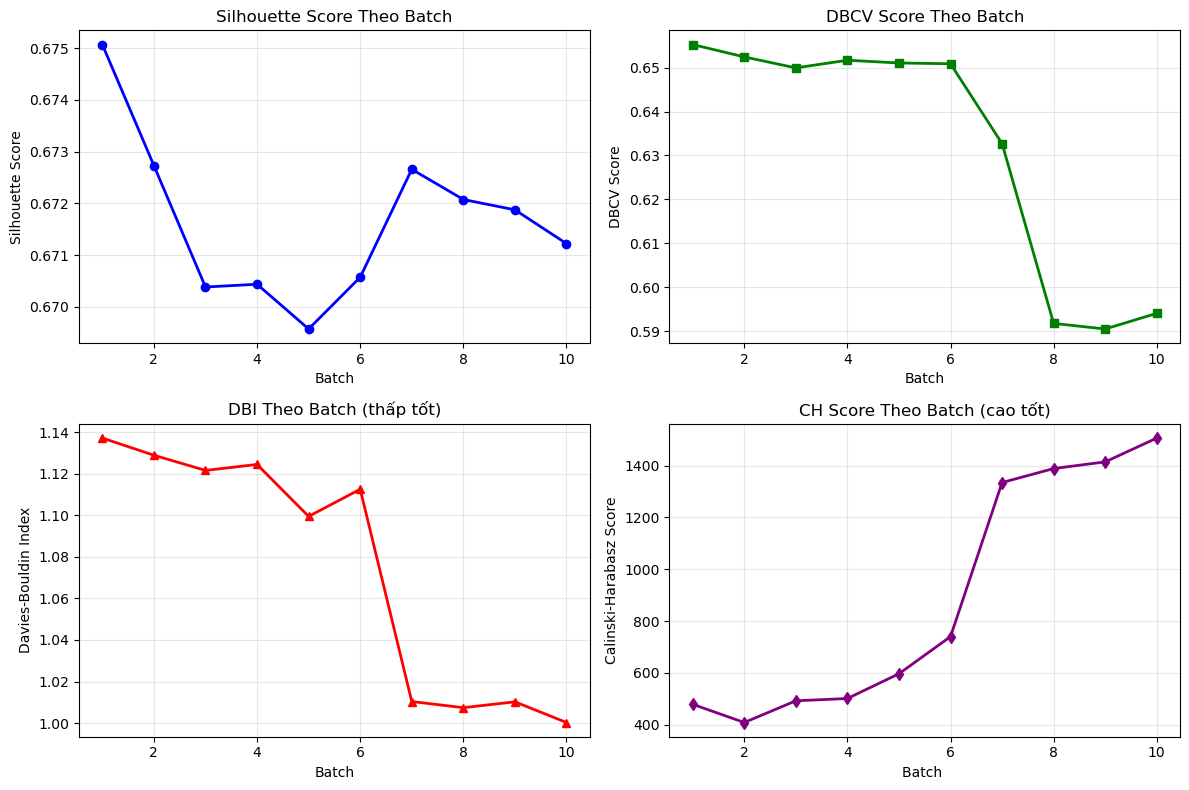

In [22]:
# Vẽ biểu đồ
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(batch_numbers, sil_list, marker='o', color='blue', linewidth=2)
plt.xlabel("Batch")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Theo Batch")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(batch_numbers, dbcv_list, marker='s', color='green', linewidth=2)
plt.xlabel("Batch")
plt.ylabel("DBCV Score")
plt.title("DBCV Score Theo Batch")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(batch_numbers, dbi_list, marker='^', color='red', linewidth=2)
plt.xlabel("Batch")
plt.ylabel("Davies-Bouldin Index")
plt.title("DBI Theo Batch (thấp tốt)")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(batch_numbers, ch_list, marker='d', color='purple', linewidth=2)
plt.xlabel("Batch ")
plt.ylabel("Calinski-Harabasz Score")
plt.title("CH Score Theo Batch (cao tốt)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()